In [8]:
from google.colab import files
import os

# 1. kaggle.json dosyasını yükleyin
print("Lütfen indirdiğiniz kaggle.json dosyasını seçin:")
uploaded = files.upload()

# 2. kaggle.json dosyasını gerekli dizine taşıyın ve izinleri ayarlayın
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Veri setini indirin ve 'brain_tumor_dataset' klasörüne zipten çıkarın
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p ./brain_tumor_dataset

print("\nİndirme tamamlandı! Klasör içeriği:")
print(os.listdir("./brain_tumor_dataset"))

Lütfen indirdiğiniz kaggle.json dosyasını seçin:


Saving kaggle (1).json to kaggle (1) (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 243MB/s]


İndirme tamamlandı! Klasör içeriği:
['Testing', 'Training']


In [9]:
from pathlib import Path

data_dir = Path("")
image_dir = data_dir / "brain_tumor_dataset"

In [10]:
import os

def show_data_content(data_dir):
  for dirpath, dirnames, filenames in os.walk(data_dir):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [26]:
show_data_content(image_dir)

There are 2 directories and 0 images in 'brain_tumor_dataset'.
There are 4 directories and 0 images in 'brain_tumor_dataset/Testing'.
There are 0 directories and 400 images in 'brain_tumor_dataset/Testing/glioma'.
There are 0 directories and 400 images in 'brain_tumor_dataset/Testing/notumor'.
There are 0 directories and 400 images in 'brain_tumor_dataset/Testing/meningioma'.
There are 0 directories and 400 images in 'brain_tumor_dataset/Testing/pituitary'.
There are 4 directories and 0 images in 'brain_tumor_dataset/Training'.
There are 0 directories and 1400 images in 'brain_tumor_dataset/Training/glioma'.
There are 0 directories and 1400 images in 'brain_tumor_dataset/Training/notumor'.
There are 0 directories and 1400 images in 'brain_tumor_dataset/Training/meningioma'.
There are 0 directories and 1400 images in 'brain_tumor_dataset/Training/pituitary'.


In [30]:
train_dir = image_dir / "Training"
test_dir = image_dir / "Testing"

In [15]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision

In [44]:
weights = torchvision.models.ResNet50_Weights.DEFAULT

In [45]:
auto_transforms = weights.transforms()

In [46]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [47]:
def create_data(train_dir: str,
                test_dir: str,
                transforms: transforms.Compose,
                batch_size: int):
  train_data = datasets.ImageFolder(
      root= train_dir,
      transform=transforms
  )
  test_data = datasets.ImageFolder(
      root=test_dir,
      transform=transforms
  )

  train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True
  )
  test_dataloader = DataLoader(
      dataset=test_data,
      batch_size=batch_size,
      shuffle=False)

  class_names = train_data.classes

  return class_names, train_dataloader, test_dataloader

In [48]:
class_names, train_dataloader, test_dataloader = create_data(
    train_dir=train_dir,
    test_dir=test_dir,
    transforms=auto_transforms,
    batch_size=32
)

In [49]:
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [51]:
device

'cuda'

In [60]:
model = torchvision.models.resnet50(weights).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [61]:
!pip install torchinfo

In [62]:
from torchinfo import summary

In [63]:
summary(model,
        input_size=(32, 3, 224, 224),
        col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 224, 224]         [32, 1000]                --                        True
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        9,408                     True
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        128                       True
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 256, 56, 56]         --                        True
│    └─Bottleneck: 2-1                   [32, 64, 56, 56]          [32, 256, 56, 56]         --                        True
│    │ 

In [64]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [65]:
model.fc = nn.Sequential(
    nn.Linear(
        in_features=2048,
        out_features=len(class_names),
        bias=True
    )
).to(device)

In [66]:
for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True

In [67]:
summary(model,
        input_size=(32, 3, 224, 224),
        col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 224, 224]         [32, 4]                   --                        Partial
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False
│    └─Bottleneck: 2-1                   [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False


In [68]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)

In [69]:
def calculate_accuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_true)) * 100
  return acc

In [71]:
def train(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    acc_fn):
  model.train()
  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    train_acc += acc_fn(y, y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [82]:
def test(
  model: nn.Module,
  dataloader: torch.utils.data.DataLoader,
  loss_fn: nn.Module,
  device: torch.device,
  acc_fn
):

  model.eval()
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      loss = loss_fn(y_pred, y)
      test_loss += loss.item()
      test_acc += acc_fn(y, y_pred.argmax(dim=1))

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

  return test_loss, test_acc

In [78]:
def train_test_step(
    model: nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    acc_fn,
    epochs: int
):
  results = {
      "train_loss" : [],
      "test_loss" : [],
      "train_acc" : [],
      "test_acc" : []
  }

  for epoch in range(epochs):
    train_loss, train_acc = train(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        acc_fn=acc_fn
    )
    test_loss, test_acc = test(
        model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        device=device,
        acc_fn=acc_fn
    )
    print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    results["train_loss"].append(train_loss if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc if isinstance(test_acc, torch.Tensor) else test_acc)

  return results

In [83]:
results = train_test_step(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    acc_fn=calculate_accuracy,
    epochs=10
)

Epoch: 1 | Train Loss: 0.2816 | Train Acc: 90.98% | Test Loss: 0.4921 | Test Acc: 84.75%
Epoch: 2 | Train Loss: 0.2571 | Train Acc: 91.41% | Test Loss: 0.4850 | Test Acc: 85.69%
Epoch: 3 | Train Loss: 0.2404 | Train Acc: 92.61% | Test Loss: 0.4907 | Test Acc: 85.38%
Epoch: 4 | Train Loss: 0.2237 | Train Acc: 92.91% | Test Loss: 0.4897 | Test Acc: 86.12%
Epoch: 5 | Train Loss: 0.2023 | Train Acc: 93.38% | Test Loss: 0.4921 | Test Acc: 86.50%
Epoch: 6 | Train Loss: 0.1957 | Train Acc: 93.82% | Test Loss: 0.4620 | Test Acc: 87.56%
Epoch: 7 | Train Loss: 0.1772 | Train Acc: 94.80% | Test Loss: 0.4620 | Test Acc: 87.56%
Epoch: 8 | Train Loss: 0.1723 | Train Acc: 94.36% | Test Loss: 0.4934 | Test Acc: 87.06%
Epoch: 9 | Train Loss: 0.1672 | Train Acc: 95.07% | Test Loss: 0.5037 | Test Acc: 87.19%
Epoch: 10 | Train Loss: 0.1594 | Train Acc: 95.02% | Test Loss: 0.5097 | Test Acc: 87.44%


In [84]:
from matplotlib import pyplot as plt

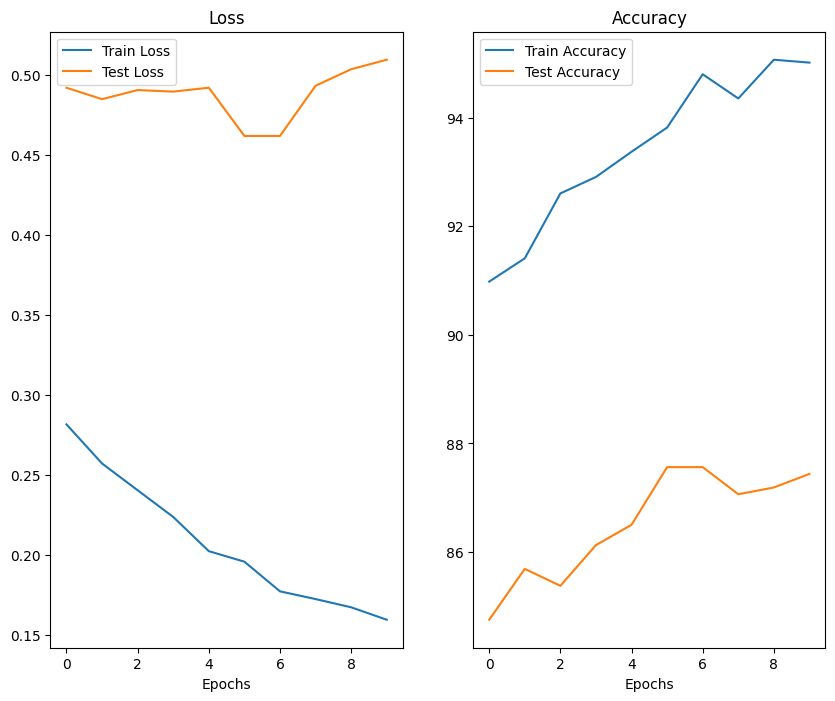

In [89]:
epochs = range(len(results["train_loss"]))

plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.plot(epochs, results['train_loss'], label = "Train Loss")
plt.plot(epochs, results['test_loss'], label = "Test Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, results['train_acc'], label = "Train Accuracy")
plt.plot(epochs, results['test_acc'], label = "Test Accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.legend()